# Exchange gates in silicon: control, noise and benchmarking

Jasper Sands · `spin_optimal_control` 0.4

This notebook goes through what the package does, in order:

1. The two-electron Hamiltonian and its spectrum
2. Optimising a $\sqrt{\mathrm{SWAP}}$ pulse
3. A CZ under a micromagnet gradient, with virtual-Z phases
4. Pulse shape and the adiabaticity of a CZ
5. Charge noise and nuclear-field fluctuations
6. Relaxation and dephasing (Lindblad), including temperature
7. Filter functions in the frame of the gate
8. Randomized benchmarking: Clifford-level and compiled to native pulses
9. Valley leakage
10. Export to an arbitrary waveform generator

Frequencies are in MHz and times in ns, so a constant $J = 10$ MHz for 50 ns is an exchange angle of $\pi$ (a SWAP).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from spin_optimal_control import (
    SiliconSpinHamiltonian, ExchangeDynamics, GRAPEOptimizer,
    SiliconNoiseModel, PinkNoiseGenerator, SiliconValleyModel,
    run_interleaved_rb, export_awg_waveforms, phase, __version__,
)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
print("spin_optimal_control", __version__)
print("Exchange angle of J = 10 MHz for 50 ns:", round(phase(10.0, 50.0) / np.pi, 4), "π")

spin_optimal_control 0.4.0
Exchange angle of J = 10 MHz for 50 ns: 1.0 π


## 1. Hamiltonian and spectrum

In the rotating frame, $H/h = \tfrac{J}{4}\,\vec\sigma_1\cdot\vec\sigma_2 + \tfrac{\Delta B_z}{2}(Z_1 - Z_2)$. The $|T_+\rangle, |T_-\rangle$ states sit at $+J/4$; the $\{|\!\uparrow\downarrow\rangle, |\!\downarrow\uparrow\rangle\}$ block has eigenvalues $-J/4 \pm \sqrt{\Delta B_z^2 + J^2/4}$. At $J \gg \Delta B_z$ the lower state is the singlet at $-3J/4$.

Detuning needed for J = 40 MHz: 0.693 mV


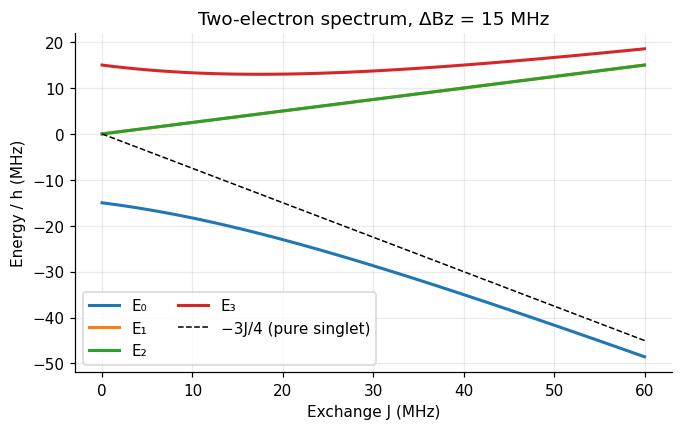

In [2]:
h = SiliconSpinHamiltonian(j_0=20.0, epsilon_0=1.0, delta_bz=15.0)
J_grid = np.linspace(0, 60, 121)
spec = np.array([h.spectrum(J) for J in J_grid])

fig, ax = plt.subplots(figsize=(7, 4))
labels = ["E₀", "E₁", "E₂", "E₃"]
for k in range(4):
    ax.plot(J_grid, spec[:, k], lw=2, label=labels[k])
ax.plot(J_grid, -0.75 * J_grid, "k--", lw=1, label="−3J/4 (pure singlet)")
ax.set_xlabel("Exchange J (MHz)"); ax.set_ylabel("Energy / h (MHz)")
ax.set_title("Two-electron spectrum, ΔBz = 15 MHz"); ax.legend(ncol=2)
plt.show()

print("Detuning needed for J = 40 MHz:", round(float(h.detuning_from_exchange(40.0)), 3), "mV")

## 2. GRAPE synthesis of √SWAP

The pulse is a band-limited Fourier series with $J(0)=J(T)=0$, clipped to $[0, J_{\max}]$. The optimiser is L-BFGS-B with JAX gradients through the time-sliced matrix exponentials. For $\sqrt{\mathrm{SWAP}}$ the exchange area must be $\int J\,dt = 250$ MHz·ns.

Fidelity          : 0.997504
Exchange area     : 250.3 MHz·ns  (target 250)
Peak J            : 40.00 MHz
Loss evaluations  : 131  (multi-start: 3)


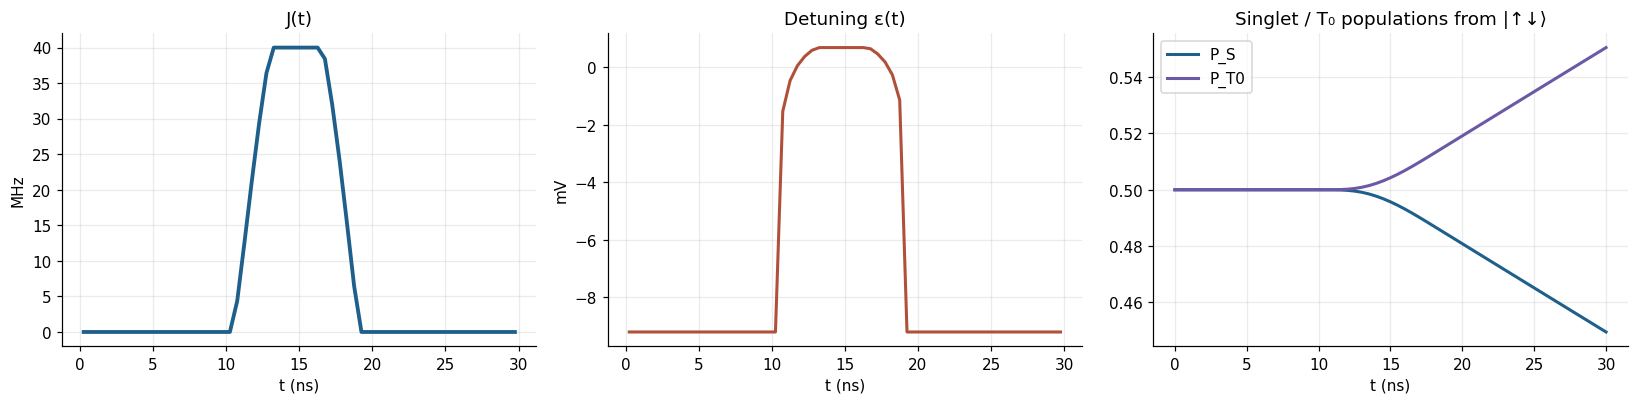

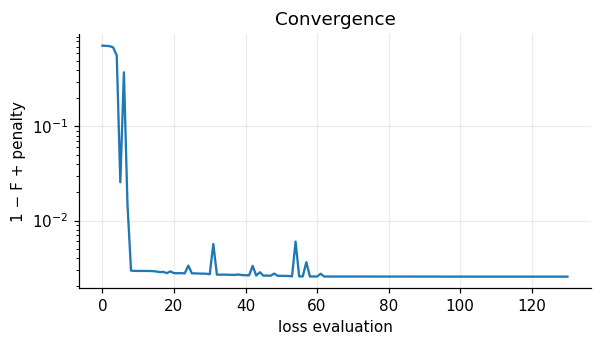

In [3]:
h_sqrt = SiliconSpinHamiltonian(j_0=20.0, delta_bz=0.5)   # 0.5 MHz residual gradient, no micromagnet
opt = GRAPEOptimizer(h_sqrt, t_gate_ns=30.0, n_steps=60, n_harmonics=5, j_max=40.0)
res = opt.optimize_pulse(ExchangeDynamics.target_gate_sqrt_swap(), max_iter=200)

print(f"Fidelity          : {res.gate_fidelity:.6f}")
print(f"Exchange area     : {res.exchange_area_mhz_ns:.1f} MHz·ns  (target 250)")
print(f"Peak J            : {res.j_pulse.max():.2f} MHz")
print(f"Loss evaluations  : {res.iterations}  (multi-start: {res.n_starts})")

dyn = ExchangeDynamics(h_sqrt)
s, t0, tp, tm = SiliconSpinHamiltonian.get_singlet_triplet_basis()
psi0 = np.array([0, 1, 0, 0], dtype=complex)   # |↑↓⟩
traj = dyn.propagate_state_trajectory(psi0, res.j_pulse, res.dt)
pops = dyn.compute_singlet_triplet_populations(traj)
t_edges = np.concatenate([[0.0], res.time_grid + res.dt / 2])

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 3.8))
a1.plot(res.time_grid, res.j_pulse, lw=2.5, color="#1f5f8b"); a1.set_title("J(t)"); a1.set_xlabel("t (ns)"); a1.set_ylabel("MHz")
a2.plot(res.time_grid, res.detuning_pulse, lw=2, color="#b0503a"); a2.set_title("Detuning ε(t)"); a2.set_xlabel("t (ns)"); a2.set_ylabel("mV")
for key, c in [("P_S", "#1f5f8b"), ("P_T0", "#6b58a6")]:
    a3.plot(t_edges, pops[key], lw=2, color=c, label=key)
a3.set_title("Singlet / T₀ populations from |↑↓⟩"); a3.set_xlabel("t (ns)"); a3.legend()
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(res.loss_history, lw=1.5); ax.set_xlabel("loss evaluation"); ax.set_ylabel("1 − F + penalty"); ax.set_title("Convergence")
plt.show()

## 3. CZ under a 30 MHz micromagnet gradient

With $\Delta B_z \gg J$ the exchange pulse produces a controlled phase, but the raw unitary also carries single-qubit Z rotations. On hardware these are free *virtual-Z* frame updates, so we let GRAPE co-optimise four Z phases (`local_z_free=True`) and report the fidelity with them applied.

Raw fidelity (no virtual-Z)   : 0.0029
Fidelity with virtual-Z       : 1.000000
Virtual-Z phases (rad)        : [-1.517 -0.054 -1.517 -0.054]
Exchange area                 : 500.0 MHz·ns  (CZ needs ≈ 500)


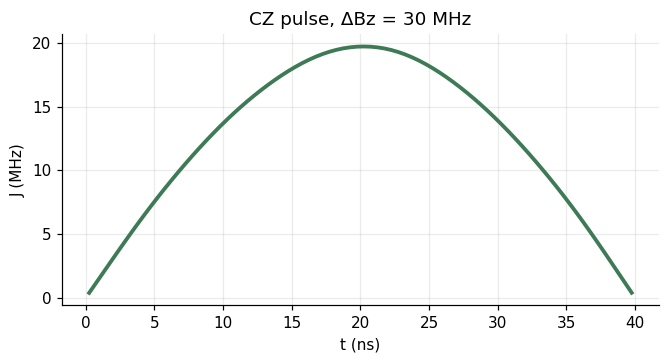

In [4]:
h_cz = SiliconSpinHamiltonian(j_0=20.0, delta_bz=30.0)
opt_cz = GRAPEOptimizer(h_cz, t_gate_ns=40.0, n_steps=80, n_harmonics=6, j_max=40.0, local_z_free=True)
res_cz = opt_cz.optimize_pulse(ExchangeDynamics.target_gate_cz(), max_iter=300)

f_raw = ExchangeDynamics.gate_fidelity(res_cz.synthesized_unitary, res_cz.target_unitary)
print(f"Raw fidelity (no virtual-Z)   : {f_raw:.4f}")
print(f"Fidelity with virtual-Z       : {res_cz.gate_fidelity:.6f}")
print(f"Virtual-Z phases (rad)        : {np.round(res_cz.virtual_z, 3)}")
print(f"Exchange area                 : {res_cz.exchange_area_mhz_ns:.1f} MHz·ns  (CZ needs ≈ 500)")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(res_cz.time_grid, res_cz.j_pulse, lw=2.5, color="#3d7a55")
ax.set_xlabel("t (ns)"); ax.set_ylabel("J (MHz)"); ax.set_title("CZ pulse, ΔBz = 30 MHz"); plt.show()

## 4. Pulse shape and the adiabaticity of a CZ

With a gradient, the conditional phase of an exchange pulse is exactly $-2\pi\cdot10^{-3}\int J\,dt$ whatever its shape (the $\{|\!\uparrow\downarrow\rangle, |\!\downarrow\uparrow\rangle\}$ block is a phase times an SU(2) matrix). So every window below is scaled to area 500 MHz·ns, and the only difference between them is how much population leaks between $|\!\uparrow\downarrow\rangle$ and $|\!\downarrow\uparrow\rangle$ when $J$ changes faster than the gap $\Delta B_z$ allows.

square    4.4e-03  2.4e-05  3.7e-06  (T = 80, 125, 200 ns)
tukey     4.4e-03  4.7e-05  3.3e-08  (T = 80, 125, 200 ns)
cosine    5.3e-05  9.8e-08  2.1e-09  (T = 80, 125, 200 ns)
blackman  2.3e-05  5.5e-09  4.3e-10  (T = 80, 125, 200 ns)


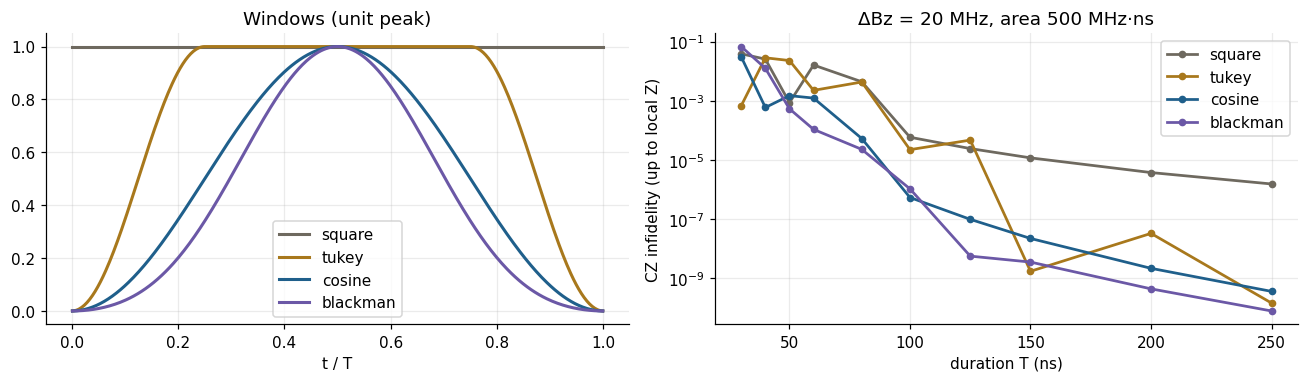

In [5]:
from spin_optimal_control import AdiabaticCZDesigner, window
designer = AdiabaticCZDesigner(SiliconSpinHamiltonian(delta_bz=20.0), n_steps=400)
durations = [30, 40, 50, 60, 80, 100, 125, 150, 200, 250]
shapes = ["square", "tukey", "cosine", "blackman"]
curves = {s: [designer.calibrate(s, T).infidelity for T in durations] for s in shapes}
for s in shapes:
    print(f"{s:9s}", "  ".join(f"{v:.1e}" for v in curves[s][4::2]), " (T = 80, 125, 200 ns)")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
colors = {"square": "#6e695f", "tukey": "#a8781c", "cosine": "#1f5f8b", "blackman": "#6b58a6"}
x = (np.arange(400) + 0.5) / 400
for s in shapes:
    a1.plot(x, window(s, 400), color=colors[s], lw=2, label=s)
    a2.semilogy(durations, curves[s], "o-", color=colors[s], lw=1.8, ms=4, label=s)
a1.set_xlabel("t / T"); a1.set_title("Windows (unit peak)"); a1.legend()
a2.set_xlabel("duration T (ns)"); a2.set_ylabel("CZ infidelity (up to local Z)"); a2.set_title("ΔBz = 20 MHz, area 500 MHz·ns"); a2.legend()
plt.tight_layout(); plt.show()

## 5. Monte-Carlo over 1/f charge noise and Overhauser shifts

Each trial draws a $1/f$ detuning trace (which multiplies $J$ through $e^{\delta\varepsilon/\varepsilon_0}$) and a quasi-static Overhauser shift of $\Delta B_z$, then re-propagates the optimised √SWAP pulse.

Mean fidelity under noise: 0.99693 ± 0.00264   (coherent limit 0.99750)


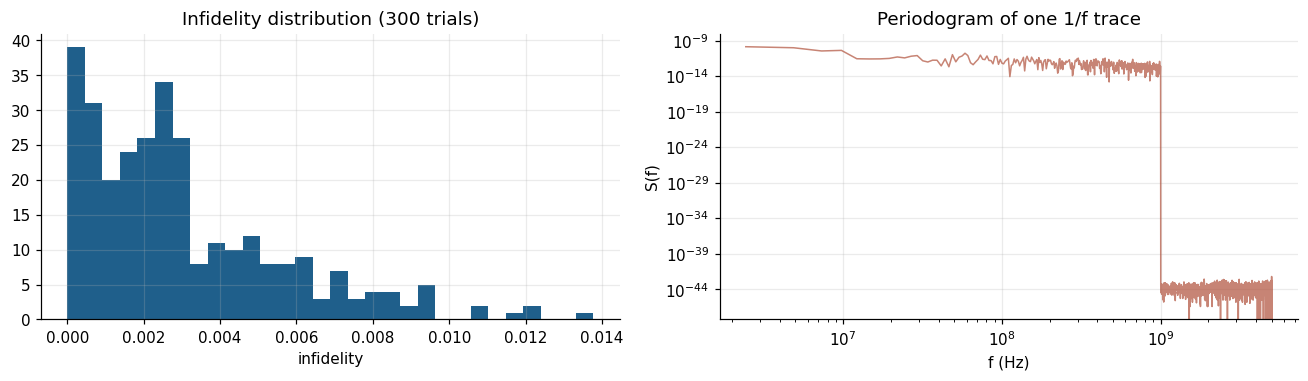

In [6]:
noise = SiliconNoiseModel(t1_us=800.0, t2_star_us=25.0, charge_noise_amp=0.04, overhauser_sigma=0.3, seed=7)
target = ExchangeDynamics.target_gate_sqrt_swap()
fids = []
for _ in range(300):
    j_n, db_n = noise.apply_noisy_pulses(res.j_pulse, h_sqrt.epsilon_0, res.dt, h_sqrt.delta_bz)
    fids.append(dyn.gate_fidelity(dyn.propagate_unitary(j_n, res.dt, db_n), target))
fids = np.array(fids)
print(f"Mean fidelity under noise: {fids.mean():.5f} ± {fids.std():.5f}   (coherent limit {res.gate_fidelity:.5f})")

gen = PinkNoiseGenerator(alpha=1.0, amplitude=0.04, seed=1)
trace = gen.generate_spectral_trace(4096, 0.1)
f_hz, psd = gen.psd_estimate(trace, 0.1)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
a1.hist(1 - fids, bins=30, color="#1f5f8b"); a1.set_xlabel("infidelity"); a1.set_title("Infidelity distribution (300 trials)")
a2.loglog(f_hz, psd, lw=1, color="#b0503a", alpha=0.7); a2.set_xlabel("f (Hz)"); a2.set_ylabel("S(f)"); a2.set_title("Periodogram of one 1/f trace")
plt.tight_layout(); plt.show()

## 6. Exact Lindblad open-system fidelity versus $T_2^*$

The Lindblad equation with $T_1$ relaxation and pure dephasing $1/T_\phi = 1/T_2^* - 1/(2T_1)$ is solved exactly per time slice by exponentiating the 16×16 Liouvillian. The process fidelity of the resulting channel against the target unitary is $\mathrm{Tr}(S_U^\dagger S_\mathcal{E})/d^2$.

T2* =     1.0 µs → F_pro = 0.96819
T2* =     2.0 µs → F_pro = 0.98269
T2* =     5.0 µs → F_pro = 0.99153
T2* =    10.0 µs → F_pro = 0.99450
T2* =    20.0 µs → F_pro = 0.99599
T2* =    50.0 µs → F_pro = 0.99689
T2* =   100.0 µs → F_pro = 0.99719
T2* =  1000.0 µs → F_pro = 0.99746
T =   0 mK, f = 1 GHz: thermal |↑⟩ population 0.000
T =  50 mK, f = 1 GHz: thermal |↑⟩ population 0.277
T = 100 mK, f = 1 GHz: thermal |↑⟩ population 0.382
T = 200 mK, f = 1 GHz: thermal |↑⟩ population 0.440


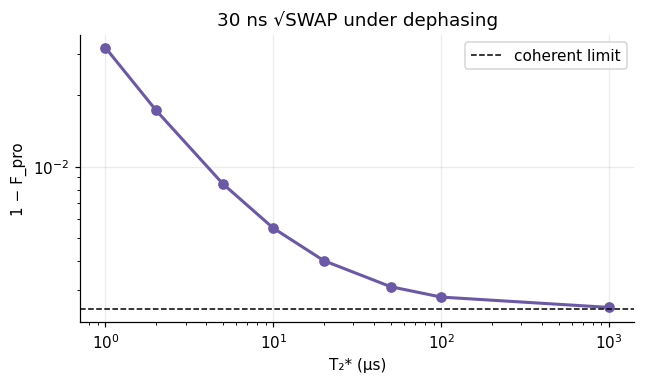

In [7]:
t2_values = np.array([1, 2, 5, 10, 20, 50, 100, 1000.0])
f_ch = [SiliconNoiseModel(t1_us=800.0, t2_star_us=t2, charge_noise_amp=0.0, overhauser_sigma=0.0)
        .channel_process_fidelity(res.j_pulse, res.dt, target, h_sqrt.get_hamiltonian_matrix) for t2 in t2_values]
for t2, f in zip(t2_values, f_ch):
    print(f"T2* = {t2:7.1f} µs → F_pro = {f:.5f}")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.semilogx(t2_values, 1 - np.array(f_ch), "o-", lw=2, color="#6b58a6")
ax.axhline(1 - res.gate_fidelity, ls="--", color="k", lw=1, label="coherent limit")
ax.set_xlabel("T₂* (µs)"); ax.set_ylabel("1 − F_pro"); ax.set_yscale("log"); ax.legend(); ax.set_title("30 ns √SWAP under dephasing")
plt.show()

# T1 is the measured relaxation time; at finite temperature it splits into decay and excitation by detailed balance.
for T_mk in (0, 50, 100, 200):
    nm = SiliconNoiseModel(t1_us=1.0, t2_star_us=1e9, charge_noise_amp=0.0, overhauser_sigma=0.0, temperature_mk=T_mk, larmor_frequency_mhz=1000.0)
    print(f"T = {T_mk:3d} mK, f = 1 GHz: thermal |↑⟩ population {nm.excited_state_population():.3f}")

## 7. Filter functions in the frame of the gate

A noise term $b(t)N$ is seen by the gate through its toggle-frame image $U_0^\dagger(t) N U_0(t)$, so the filter function depends on the whole trajectory, not only on the pulse envelope. `gate_filter_functions` integrates each time slice exactly in its eigenbasis. Below, the first-order prediction for Ornstein–Uhlenbeck frequency noise on one electron during a cosine CZ is compared with a direct Monte-Carlo simulation.

τc =  2.0 ns: filter function 3.474e-04, Monte-Carlo 3.262e-04 ± 3.4e-05
τc = 20.0 ns: filter function 2.811e-03, Monte-Carlo 3.385e-03 ± 3.7e-04


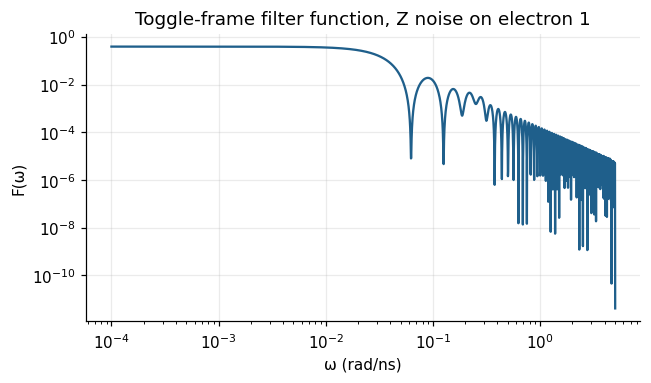

In [8]:
import scipy.linalg
from spin_optimal_control.noise import exchange_gate_noise_operators, gate_filter_functions, infidelity_from_filter_function
from spin_optimal_control.units import MHZ_NS_TO_RAD
hz = SiliconSpinHamiltonian(delta_bz=20.0)
cz = AdiabaticCZDesigner(hz, n_steps=160).calibrate("cosine", 100.0)
Hs = [hz.get_hamiltonian_matrix(float(x)) for x in cz.j_pulse]
ops = exchange_gate_noise_operators(cz.j_pulse, "zeeman1")
omega = np.concatenate([[0.0], np.logspace(-4, np.log10(np.pi / cz.dt_ns), 2500)])
F = gate_filter_functions(Hs, cz.dt_ns, ops, omega)[0]

def propagate(extra):
    U = np.eye(4, dtype=complex)
    for k in range(len(Hs)):
        U = scipy.linalg.expm(-1j * MHZ_NS_TO_RAD * (Hs[k] + extra[k]) * cz.dt_ns) @ U
    return U
U0 = propagate([0] * len(Hs))
rng = np.random.default_rng(0)
for tc in (2.0, 20.0):
    sig = 0.3
    pred = infidelity_from_filter_function(omega, F, 2 * sig**2 * 2 * tc / (1 + (omega * tc) ** 2))
    decay = np.exp(-cz.dt_ns / tc); vals = []
    for _ in range(150):
        x = np.empty(len(Hs)); x[0] = rng.normal(0, sig)
        for k in range(1, len(Hs)):
            x[k] = decay * x[k - 1] + np.sqrt(1 - decay**2) * sig * rng.normal()
        vals.append(1 - abs(np.trace(U0.conj().T @ propagate([xk * ops[0][0] for xk in x]))) ** 2 / 16)
    print(f"τc = {tc:4.1f} ns: filter function {pred:.3e}, Monte-Carlo {np.mean(vals):.3e} ± {np.std(vals)/np.sqrt(len(vals)):.1e}")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.loglog(omega[1:], F[1:], color="#1f5f8b", lw=1.5)
ax.set_xlabel("ω (rad/ns)"); ax.set_ylabel("F(ω)"); ax.set_title("Toggle-frame filter function, Z noise on electron 1")
plt.show()

## 8. Two-qubit Clifford randomized benchmarking in Cirq

`generate_two_qubit_cliffords()` builds the full 11 520-element group by closure of $\{H\otimes I, I\otimes H, S\otimes I, I\otimes S, \mathrm{CNOT}\}$. Reference and interleaved sequences are simulated with the silicon $T_1/T_\phi$ channels; the interleaved gate error is $r = \tfrac{3}{4}(1 - p_\mathrm{int}/p_\mathrm{ref})$.

Two-qubit Clifford group order: 11520
p_ref = 0.99858   p_int = 0.99636   gate error = 1.67e-03


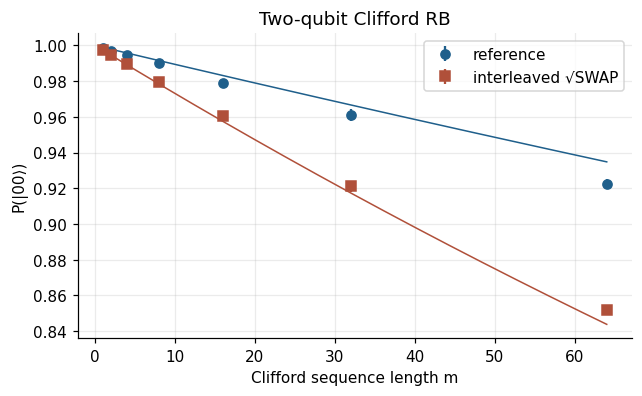

In [9]:
from spin_optimal_control import generate_two_qubit_cliffords
print("Two-qubit Clifford group order:", len(generate_two_qubit_cliffords()))

lengths = [1, 2, 4, 8, 16, 32, 64]
rb = run_interleaved_rb(res.synthesized_unitary, lengths, n_sequences_per_length=10, noise_model=noise, seed=3)
print(f"p_ref = {rb['decay_p_ref']:.5f}   p_int = {rb['decay_p_interleaved']:.5f}   gate error = {rb['gate_error']:.2e}")

m = np.linspace(1, 64, 200)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.errorbar(lengths, rb["ref_fidelities"], yerr=rb["ref_std_errors"], fmt="o", color="#1f5f8b", label="reference")
ax.errorbar(lengths, rb["interleaved_fidelities"], yerr=rb["interleaved_std_errors"], fmt="s", color="#b0503a", label="interleaved √SWAP")
ax.plot(m, 0.75 * rb["decay_p_ref"] ** m + 0.25, color="#1f5f8b", lw=1)
ax.plot(m, 0.75 * rb["decay_p_interleaved"] ** m + 0.25, color="#b0503a", lw=1)
ax.set_xlabel("Clifford sequence length m"); ax.set_ylabel("P(|00⟩)"); ax.legend(); ax.set_title("Two-qubit Clifford RB")
plt.show()

That model treats each Clifford as one ideal layer. An experiment instead compiles every Clifford to native gates: here ±X/2 and ±Y/2 pulses, free virtual-Z frame updates and the CZ. `CompiledCliffordRB` does that for all 11 520 Cliffords (1.5 CZ each on average) and applies noise per physical gate, including the coherent leakage of a shaped CZ.

In [10]:
from spin_optimal_control import CompiledCliffordRB
from spin_optimal_control.cirq_backend import best_z_corrected_cz
U_cz = best_z_corrected_cz(ExchangeDynamics(hz).propagate_unitary(cz.j_pulse, cz.dt_ns))
nm = SiliconNoiseModel(t1_us=1000.0, t2_star_us=20.0, charge_noise_amp=0.0, overhauser_sigma=0.0)
crb = CompiledCliffordRB(nm, t_pulse_ns=50.0, t_cz_ns=100.0, p_pulse=1e-3, cz_unitary=U_cz)
lengths_n = [1, 4, 8, 16, 32, 64]
ref = crb.run(lengths_n, n_sequences=30, seed=5)
irb = crb.run_interleaved_cz(lengths_n, n_sequences=30, seed=6)
print(f"{ref['mean_cz_per_clifford']:.2f} CZ and {ref['mean_pulse_layers_per_clifford']:.2f} pulse layers per Clifford, {ref['mean_clifford_duration_ns']:.0f} ns on average")
print(f"error per Clifford {ref['clifford_error']:.2e}, interleaved CZ error {irb['cz_error']:.2e}")
print(crb.circuit(6000))

1.50 CZ and 2.48 pulse layers per Clifford, 274 ns on average
error per Clifford 1.36e-02, interleaved CZ error 5.67e-03
0: ───@───Rx(-0.5π)───@───S───Rx(-0.5π)───
      │               │
1: ───@───Rx(-0.5π)───@───────────────────


## 9. Valley leakage

An effective valley pseudo-spin split by $E_v$ is coupled to the spin manifold through an inter-valley spin–orbit term. Leakage out of the computational valley scales as $(\Delta_\mathrm{soc}/E_v)^2$.

E_v =   30 µeV → max leakage 1.90e-06
E_v =   50 µeV → max leakage 6.84e-07
E_v =  100 µeV → max leakage 1.71e-07
E_v =  150 µeV → max leakage 7.58e-08
E_v =  200 µeV → max leakage 4.26e-08
E_v =  300 µeV → max leakage 1.90e-08


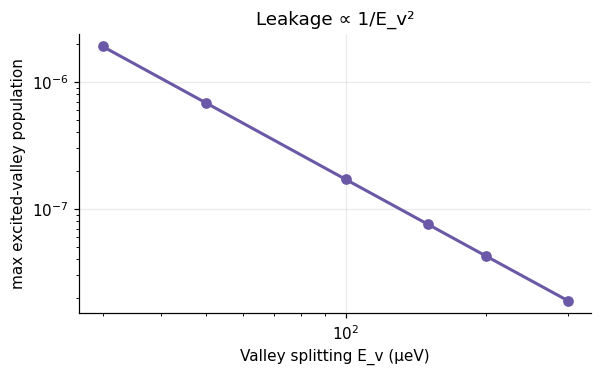

In [11]:
ev_values = [30, 50, 100, 150, 200, 300]
leak = []
for ev in ev_values:
    vm = SiliconValleyModel(valley_splitting_uev=ev, inter_valley_soc_mhz=2.5)
    leak.append(vm.compute_valley_leakage(res.j_pulse, dt_ns=res.dt, delta_bz=h_sqrt.delta_bz)["max_valley_leakage"])
for ev, l in zip(ev_values, leak):
    print(f"E_v = {ev:4d} µeV → max leakage {l:.2e}")

fig, ax = plt.subplots(figsize=(6, 3.3))
ax.loglog(ev_values, leak, "o-", lw=2, color="#6b58a6")
ax.set_xlabel("Valley splitting E_v (µeV)"); ax.set_ylabel("max excited-valley population"); ax.set_title("Leakage ∝ 1/E_v²")
plt.show()

## 10. Export to the AWG

Waveforms are resampled to the instrument rate over the full gate window and written in Qblox format (`{"waveforms": {name: {"data": [...], "index": i}}}`).

In [12]:
import json, tempfile, os
path = os.path.join(tempfile.gettempdir(), "sqrt_swap_qblox.json")
data = export_awg_waveforms(res.time_grid, res.j_pulse, res.detuning_pulse, sample_rate_gsps=1.0,
                            export_format="qblox", file_path=path)
payload = json.load(open(path))
print("Samples:", data["metadata"]["num_samples"], "| channels:", list(payload["waveforms"]))
print("First 8 J samples (MHz):", payload["waveforms"]["exchange_j_mhz"]["data"][:8])

Samples: 30 | channels: ['exchange_j_mhz', 'detuning_eps_mv']
First 8 J samples (MHz): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
